In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
df = pd.read_csv("winequality-white.csv", sep=';')
X = df.drop(columns=['quality'])
y = df['quality']

Cechy o najwyższej wariancji: ['total sulfur dioxide', 'free sulfur dioxide', 'residual sugar', 'alcohol']


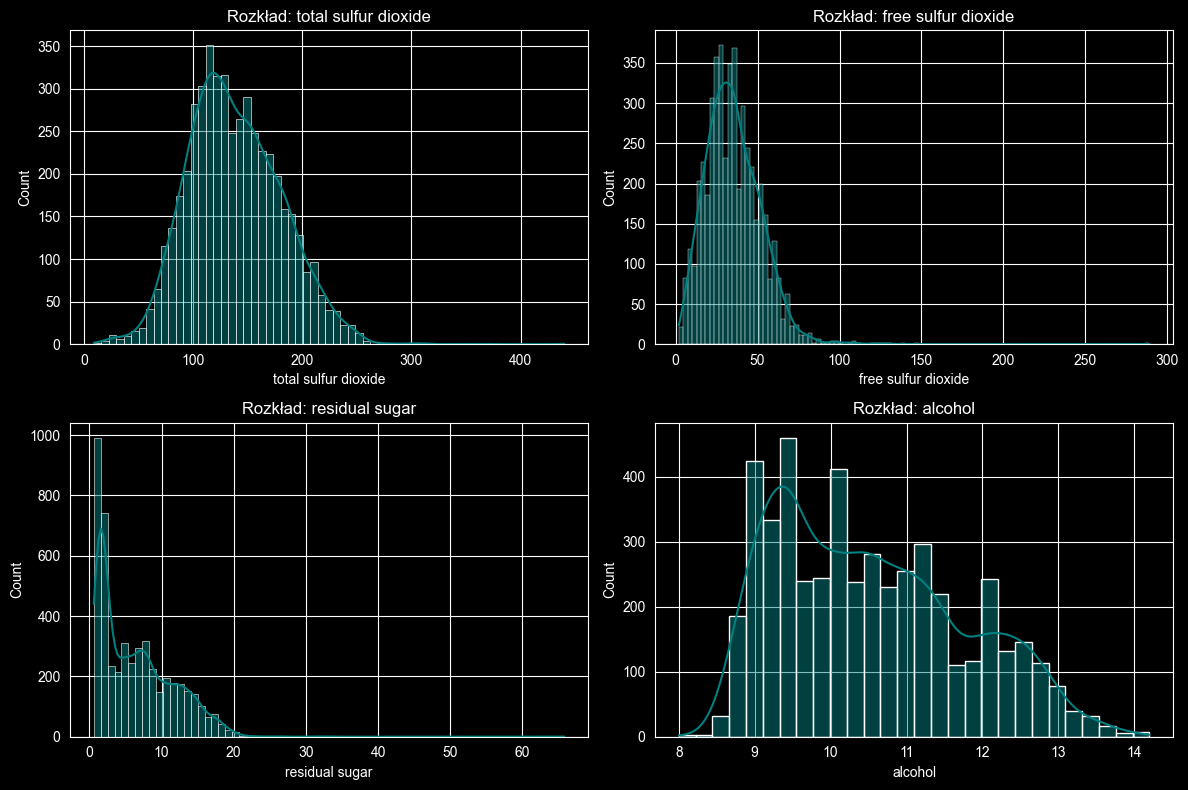

In [33]:
#Zadanie 1
variances = X.var().sort_values(ascending=False)
top_4_vars = variances.head(4).index.tolist()
print(f"Cechy o najwyższej wariancji: {top_4_vars}")
plt.figure(figsize=(12, 8))
for i, col in enumerate(top_4_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Rozkład: {col}')
plt.tight_layout()
plt.show()

In [34]:
#Zadanie 2
def find_outlier_columns(data):
    outlier_cols = []
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        if ((data[col] < lower_bound) | (data[col] > upper_bound)).any():
            outlier_cols.append(col)
    return outlier_cols
outliers_found = find_outlier_columns(X)
print(f"Cechy z wartościami odstającymi: {outliers_found}")

Cechy z wartościami odstającymi: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']


In [35]:
#Zadanie 3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scalers = {
    "Brak skalowania": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}
results_3 = {}
print("Wyniki: ")
for name, scaler in scalers.items():
    if scaler:
        pipe = Pipeline([('scaler', scaler), ('clf', LogisticRegression(max_iter=10000))])
    else:
        pipe = Pipeline([('clf', LogisticRegression(max_iter=10000))])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    results_3[name] = acc
    print(f" - {name}: {acc:.4f}")

Wyniki: 


C:\Users\astap\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 - Brak skalowania: 0.5153
 - StandardScaler: 0.5316
 - MinMaxScaler: 0.5184
 - RobustScaler: 0.5296


In [36]:
#Zadanie 4
preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), outliers_found)
    ],
    remainder='passthrough'
)
pipe_selective = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=10000))
])
pipe_selective.fit(X_train, y_train)
selective_acc = accuracy_score(y_test, pipe_selective.predict(X_test))
print(f"Zadanie 4: Wynik: {selective_acc:.4f}")
print("Odpowiedzi na pytania:")
print("1. Czy sam fakt występowania outlierów jest wskazówką do skalowania? \nTak, ale przede wszystkim jest wskazówką do wyboru odpowiedniej metody skalowania. Wartości odstające mogą drastycznie zniekształcić średnią i odchylenie standardowe, co sprawia, że standardowe metody (jak Z-score) mogą stać się mało efektywne.")
print("2. Czy obecność outlierów wpływa na wybór metody? \nZdecydowanie tak. Jeśli dane zawierają outliery, RobustScaler jest lepszym wyborem niż StandardScaler czy MinMaxScaler. RobustScaler używa mediany i rozstępu międzykwartylowego (IQR), dzięki czemu wartości ekstremalne nie \"ściągają\" reszty danych do bardzo wąskiego zakresu.")
print("3. Jaki inny czynnik kwalifikuje cechę do skalowania? \nRóżnica w rzędach wielkości (skali) cech. Nawet jeśli nie ma wartości odstających, model (np. regresja logistyczna, SVM czy k-NN) może nadać większą wagę cechom o większych wartościach liczbowych (np. \"total sulfur dioxide\" vs \"chlorides\"). Skalowanie wyrównuje \"szanse\" wszystkich cech w procesie uczenia.")

Zadanie 4: Wynik: 0.5296
Odpowiedzi na pytania:
1. Czy sam fakt występowania outlierów jest wskazówką do skalowania? 
Tak, ale przede wszystkim jest wskazówką do wyboru odpowiedniej metody skalowania. Wartości odstające mogą drastycznie zniekształcić średnią i odchylenie standardowe, co sprawia, że standardowe metody (jak Z-score) mogą stać się mało efektywne.
2. Czy obecność outlierów wpływa na wybór metody? 
Zdecydowanie tak. Jeśli dane zawierają outliery, RobustScaler jest lepszym wyborem niż StandardScaler czy MinMaxScaler. RobustScaler używa mediany i rozstępu międzykwartylowego (IQR), dzięki czemu wartości ekstremalne nie "ściągają" reszty danych do bardzo wąskiego zakresu.
3. Jaki inny czynnik kwalifikuje cechę do skalowania? 
Różnica w rzędach wielkości (skali) cech. Nawet jeśli nie ma wartości odstających, model (np. regresja logistyczna, SVM czy k-NN) może nadać większą wagę cechom o większych wartościach liczbowych (np. "total sulfur dioxide" vs "chlorides"). Skalowanie wyró